### EDA : Building a Data DashBoard
1. Ingesting raw api data
2. cleaning with pandas
3. visualizing insights
4. simple streamlit demo
   
> We are going to build a data dashboard
* Flow : 
  api-->Pandas-->Analysis--->Visualization--->Streamlit App

  1. Fetch data
  2. Raw json
  3. clean and structure 
  4. EDA
  5. Visualization
  6. Interactive dashboard

In [44]:
import requests
import pandas as pd 
import plotly.express as px
import matplotlib.pyplot as plt


In [12]:
url="https://jsonplaceholder.typicode.com/posts"

response=requests.get(url)
if response.status_code==200:
    data=response.json()
else:
    print(response.status_code)

df=pd.DataFrame(data)



In [13]:
# Checking th estructure of the data
print("The shape of the dataframe is : ")
print(df.shape)
print("-"*50)
print("Printing the structural summary of data : ")
print(df.info())
print("-"*50)
print("Printing the statistical summary of the data : ")
print(df.describe())

# Cleaning of data
# rename the column from userID to user_id 
# and drop column id 
df=df.rename(columns={
    "userId":"user_id"
})
df=df.drop("id",axis=1)
print("The resulting data :--> ")
df


The shape of the dataframe is : 
(100, 4)
--------------------------------------------------
Printing the structural summary of data : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   userId  100 non-null    int64 
 1   id      100 non-null    int64 
 2   title   100 non-null    object
 3   body    100 non-null    object
dtypes: int64(2), object(2)
memory usage: 3.3+ KB
None
--------------------------------------------------
Printing the statistical summary of the data : 
           userId          id
count  100.000000  100.000000
mean     5.500000   50.500000
std      2.886751   29.011492
min      1.000000    1.000000
25%      3.000000   25.750000
50%      5.500000   50.500000
75%      8.000000   75.250000
max     10.000000  100.000000
The resulting data :--> 


,user_id,title,body
0,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
...,...,...,...
95,10,quaerat velit veniam amet cupiditate aut numqu...,in non odio excepturi sint eum\nlabore volupta...
96,10,quas fugiat ut perspiciatis vero provident,eum non blanditiis soluta porro quibusdam volu...
97,10,laboriosam dolor voluptates,doloremque ex facilis sit sint culpa\nsoluta a...
98,10,temporibus sit alias delectus eligendi possimu...,quo deleniti praesentium dicta non quod\naut e...


In [ ]:
# Further Cleaning data
# 1. Printing the post per user using the 
Post_per_User=df.groupby("user_id").count()
print("No of Posts by each user : ")
print(Post_per_User)
# Adding  a column of length of each post
df["Post_Length"]=df["body"].apply(len)
df

         title  body  Post_Length
user_id                          
1           10    10           10
2           10    10           10
3           10    10           10
4           10    10           10
5           10    10           10
6           10    10           10
7           10    10           10
8           10    10           10
9           10    10           10
10          10    10           10


,user_id,title,body,Post_Length
0,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...,158
1,1,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...,206
2,1,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...,164
3,1,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...,190
4,1,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...,147
...,...,...,...,...
95,10,quaerat velit veniam amet cupiditate aut numqu...,in non odio excepturi sint eum\nlabore volupta...,128
96,10,quas fugiat ut perspiciatis vero provident,eum non blanditiis soluta porro quibusdam volu...,215
97,10,laboriosam dolor voluptates,doloremque ex facilis sit sint culpa\nsoluta a...,120
98,10,temporibus sit alias delectus eligendi possimu...,quo deleniti praesentium dicta non quod\naut e...,109


In [43]:
# EDA 
# Step 1 : Analysing the data  Structure 
print("The Stuctural Summary of data is : ")
print(df.info())
print("-"*60)
print("The Statistical summary of data is : ")
print(df.describe())
print("#"*120)

# Step 2 : Handelling missing data , incorrect datatype , or unrealistic data

print("-"*60)
print("These are the null values per column : ")
print(df.isnull().sum())
print("-"*60)
print("Printing first and last 5 rows of df : ")
print(df.head())
print(df.tail())
    # Observation : The observation is that there is no null value in df and and all the datatypes are correct


# step 3 : cheking the distribution of the data using histogram 
print("#"*120)
print("The distribution of data in DF : ")
fig=px.histogram(
    df,
    x="user_id",
    title="Distribution of data per user"
)

fig.show()
        # Observation : Surprisingly , distribution is uniform among the whole data .

# Step 4 : Checking the outliers using box plot
print("#"*120)
print("Analysing the Outliers : ")
fig=px.box(
    df,
    x="user_id",
    title="Outlier summary"
)
fig.show()
        # Observation : There is no outliers in data

# Step 5 : Analysing the coorelation bitween the diffrent variablea in dataframe 
crr=df.corr(numeric_only=True)

fig=px.imshow(
    crr,
    title="Correaltion bitween the numerical data in df"
)

fig.show()  



The Stuctural Summary of data is : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      100 non-null    int64 
 1   title        100 non-null    object
 2   body         100 non-null    object
 3   Post_Length  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB
None
------------------------------------------------------------
The Statistical summary of data is : 
          user_id  Post_Length
count  100.000000   100.000000
mean     5.500000   160.640000
std      2.886751    28.756561
min      1.000000   102.000000
25%      3.000000   137.500000
50%      5.500000   163.000000
75%      8.000000   180.250000
max     10.000000   225.000000
########################################################################################################################
------------------------------------------------------------


########################################################################################################################
Analysing the Outliers : 


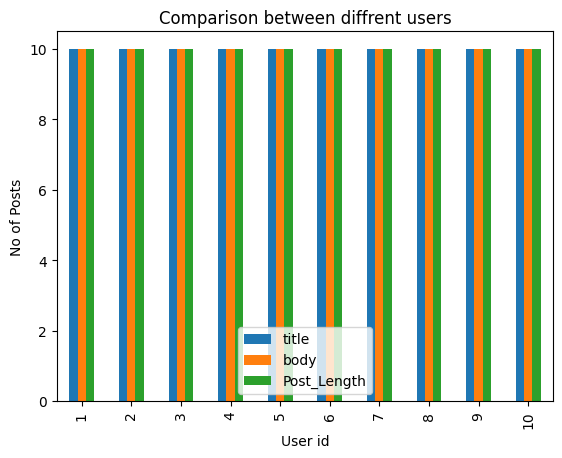

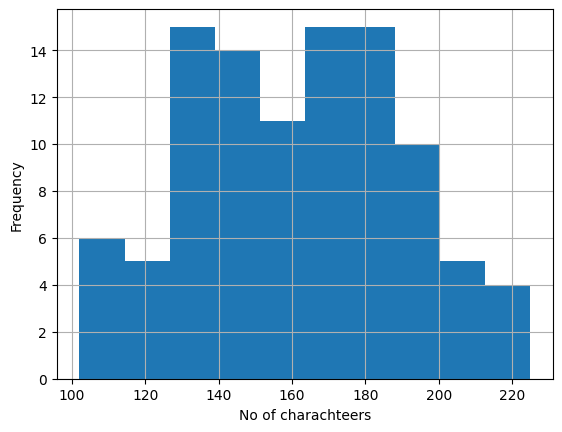

In [54]:
# First bar grph showing the comparison of diffrent users
Post_per_User.plot(kind='bar')
plt.xlabel("User id")
plt.ylabel("No of Posts")
plt.title("Comparison between diffrent users")
plt.show()

df["Post_Length"].hist()
plt.xlabel("No of charachteers")
plt.ylabel("Frequency")
plt.show("Distribution of Post Length")
plt.show()